In [1]:
# pip install matplotlib

# Plotting and Visualization

In [2]:
import numpy as np
import pandas as pd
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_rows = 20
np.random.seed(12345)
import matplotlib.pyplot as plt
import matplotlib
plt.rc('figure', figsize=(10, 6))
np.set_printoptions(precision=4, suppress=True)

In [3]:
#this enables interactive use of matplotlib
##%matplotlib notebook 
%matplotlib inline

In [4]:
import matplotlib.pyplot as plt

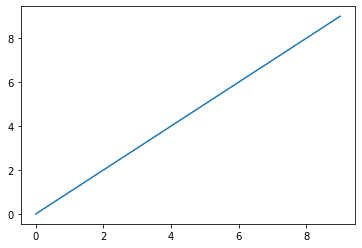

In [5]:
import numpy as np
data = np.arange(10)
plt.plot(data)

### Figures and Subplots

In [6]:
plt.close('all')
#creating a new blank figure
fig = plt.figure()

<Figure size 432x288 with 0 Axes>

In [7]:
#creating an axis object (that is, a window within the figure where a graph will be created);
#first 2 means there are 2 rows of axes, second 2 means there are 2 columns of axes (so, 4 graphs in total),
#while the number 1 means that ax1 is the the 1st of these 4 axes.
ax1 = fig.add_subplot(2, 2, 1)

In [8]:
#ax2 is the 2nd of the 4 axes, which by convention is the 2nd axis in the 1st row 
#ax3 is the 3rd of the 4 axes, which by convention is the 1st axis in the 2nd row 
#(so, by convention, the enumeration is done row-wise)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

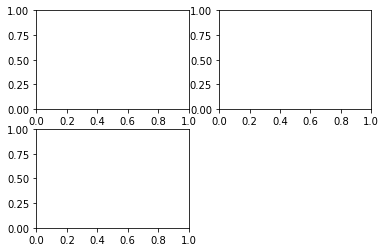

In [9]:

fig = plt.figure() 
ax1 = fig.add_subplot(2, 2, 1) 
ax2 = fig.add_subplot(2, 2, 2)  
ax3 = fig.add_subplot(2, 2, 3) 


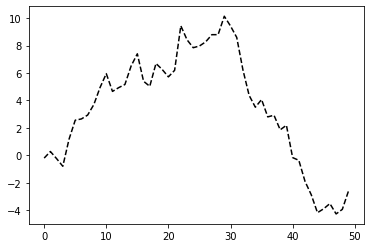

In [10]:
plt.plot(np.random.randn(50).cumsum(), 'k--')

In [11]:
ax1.hist(np.random.randn(100), bins=20, color='r', alpha=1)
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.randn(30), color=[140/255,29/255,64/255])

In [12]:
plt.close('all')

The matlab method plt.subplots (not 's' at the end) creates a tuple, whose first component is a new figure and the 2nd one is a numpy array containing the created subplot objects. This is convenient, as it creates nice indexing for easier access of each subplot. If the created numpy array of subplots is called axes, then, for example, axes[0,1] means subplot in the 1st row and 2nd column.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001F1CF3AB3C8>,
      dtype=object)

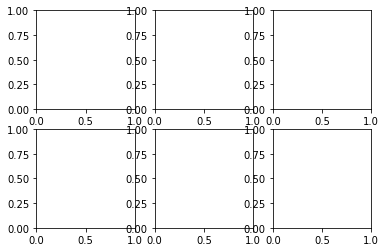

In [13]:
fig, axes = plt.subplots(2, 3)
axes

#### Adjusting the spacing around subplots

subplots_adjust(left=None, bottom=None, right=None, top=None,
                wspace=None, hspace=None)

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)
plt.subplots_adjust(wspace=0, hspace=0)

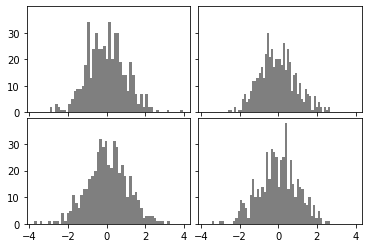

In [14]:
#sharex=True means that all subplots have the same x-axis, which is convenient when we compare data on the same scale.
#Similarly for sharey=True
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        #accessing (i,j)-subplot (convenient indexing)
        axes[i, j].hist(np.random.randn(500), bins=50, color='k', alpha=0.5)
plt.subplots_adjust(wspace=0.05, hspace=0.05) #controlling spacing between subplots - width-space and height-space

### Colors, Markers, and Line Styles

ax.plot(x, y, 'g--')

ax.plot(x, y, linestyle='--', color='g')

In [15]:
plt.figure()

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

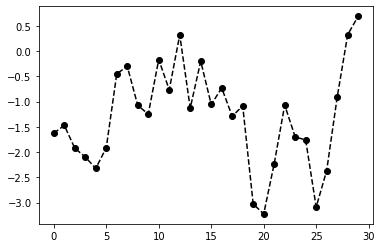

In [16]:
from numpy.random import randn
plt.plot(randn(30).cumsum(), 'ko--')

plot(randn(30).cumsum(), color='k', linestyle='dashed', marker='o')

In [17]:
plt.close('all')

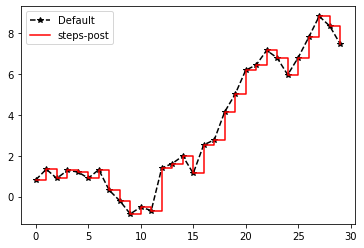

In [18]:
data = np.random.randn(30).cumsum()
plt.plot(data, 'k*--', label='Default')
plt.plot(data, 'r-', drawstyle='steps-post', label='steps-post')
plt.legend(loc='upper left')   #see also plt.legend(loc='best')

### Ticks, Labels, and Legends

#### Setting the title, axis labels, ticks, and ticklabels

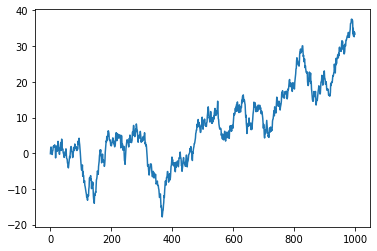

In [19]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())

In [20]:
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                            rotation=30, fontsize='small')

In [21]:
ax.set_title('My first matplotlib plot')
ax.set_xlabel('Stages')

Text(0.5, 3.1999999999999993, 'Stages')

props = {
    'title': 'My first matplotlib plot',
    'xlabel': 'Stages'
}
ax.set(**props)

#### Adding legends

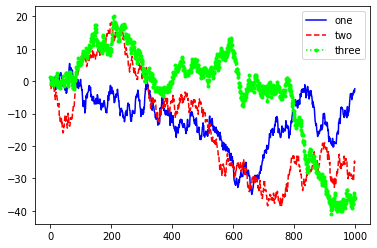

In [22]:
plt.close('all')
from numpy.random import randn
fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'b', label='one')
ax.plot(randn(1000).cumsum(), 'r--', label='two')
ax.plot(randn(1000).cumsum(), linestyle='dotted', color=[0,1,0],marker='.', markersize=6, label='three')
ax.legend(loc='best')

### Annotations and Drawing on a Subplot

ax.text(x, y, 'Hello world!',
        family='monospace', fontsize=10)

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

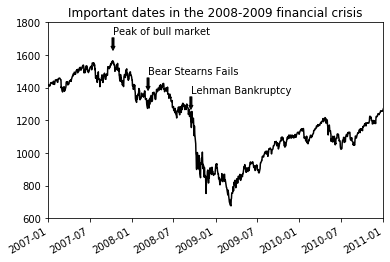

In [23]:
from datetime import datetime

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

data = pd.read_csv('examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']

spx.plot(ax=ax, style='k-')

crisis_data = [
    (datetime(2007, 10, 11), 'Peak of bull market'),
    (datetime(2008, 3, 12), 'Bear Stearns Fails'),
    (datetime(2008, 9, 15), 'Lehman Bankruptcy')
]

for date, label in crisis_data:
    ax.annotate(label, xy=(date, spx.asof(date) + 75),
                xytext=(date, spx.asof(date) + 225),
                arrowprops=dict(facecolor='black', headwidth=4, width=2,
                                headlength=4),
                horizontalalignment='left', verticalalignment='top')

# Zoom in on 2007-2010
ax.set_xlim(['1/1/2007', '1/1/2011'])
ax.set_ylim([600, 1800])

ax.set_title('Important dates in the 2008-2009 financial crisis')

In [24]:
ax.set_title('Important dates in the 2008–2009 financial crisis')

Text(0.5, 1, 'Important dates in the 2008–2009 financial crisis')

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='g', alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

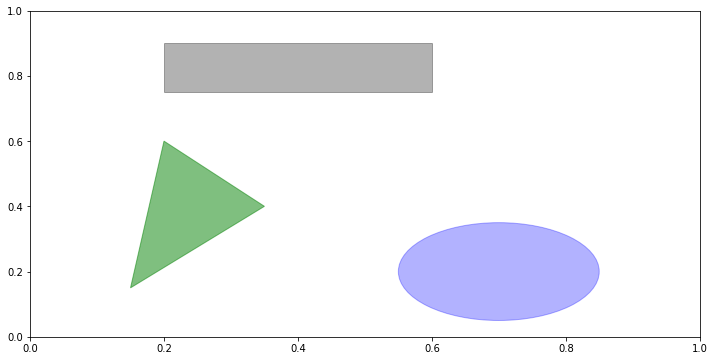

In [25]:
fig = plt.figure(figsize=(12, 6)); ax = fig.add_subplot(1, 1, 1)
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='k', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='b', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='g', alpha=0.5)
ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

### Saving Plots to File

plt.savefig('figpath.svg')

plt.savefig('figpath.png', dpi=400, bbox_inches='tight')

from io import BytesIO
buffer = BytesIO()
plt.savefig(buffer)
plot_data = buffer.getvalue()

### matplotlib Configuration

plt.rc('figure', figsize=(10, 10))

font_options = {'family' : 'monospace',
                'weight' : 'bold',
                'size'   : 'small'}
plt.rc('font', **font_options)

## Plotting with pandas and seaborn

### Line Plots

In [26]:
plt.close('all')

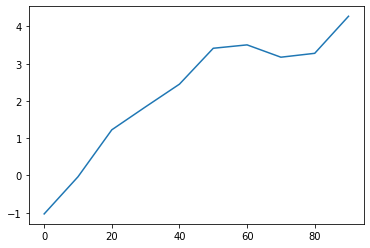

In [27]:
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()

           A         B         C         D
0  -0.300582 -0.048133  1.632680 -0.220245
10 -0.197161 -1.003471  2.940077  1.213061
20  1.569698  0.035687  2.629889  1.021479
30  2.430165 -0.422330  3.488542 -0.618687
40  0.460257  0.227451  3.706541  1.268889
50  1.634297  1.324463  4.148915  2.073691
60  3.800480  1.378821  4.696070  2.946409
70  2.771598  0.259866  6.126475  2.150240
80  1.691065  1.539425  6.898577  2.877559
90  1.673416  2.363094  7.933123  3.034758


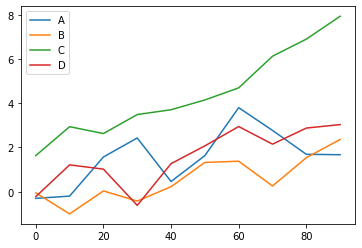

In [28]:
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index=np.arange(0, 100, 10))  #from [0 to 100) by 10; so: 0, 10, 20, ... , 90
print(df)
df.plot()

### Bar Plots

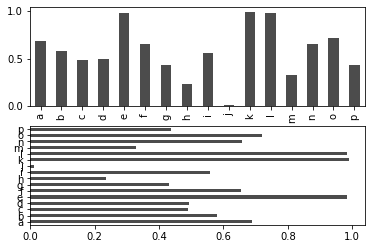

In [29]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.rand(16), index=list('abcdefghijklmnop'))
data.plot.bar(ax=axes[0], color='k', alpha=0.7)
data.plot.barh(ax=axes[1], color='k', alpha=0.7)

In [30]:
np.random.seed(12348)

In [31]:
df = pd.DataFrame(np.random.rand(6, 4),
                  index=['one', 'two', 'three', 'four', 'five', 'six'],
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df

Genus,A,B,C,D
one,0.370670,0.602792,0.229159,0.486744
two,0.420082,0.571653,0.049024,0.880592
three,0.814568,0.277160,0.880316,0.431326
four,0.374020,0.899420,0.460304,0.100843
five,0.433270,0.125107,0.494675,0.961825
six,0.601648,0.478576,0.205690,0.560547


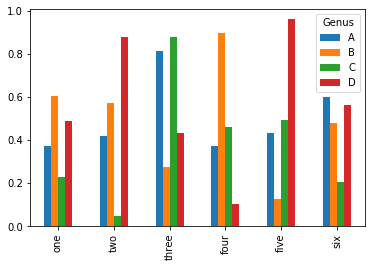

In [32]:
df.plot.bar()

In [33]:
plt.figure()

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

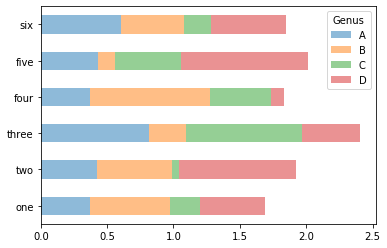

In [34]:
df.plot.barh(stacked=True, alpha=0.5)

In [35]:
plt.close('all')

In [36]:
tips = pd.read_csv('examples/tips.csv')
party_counts = pd.crosstab(tips['day'], tips['size'])
party_counts
# Not many 1- and 6-person parties
party_counts = party_counts.loc[:, 2:5]

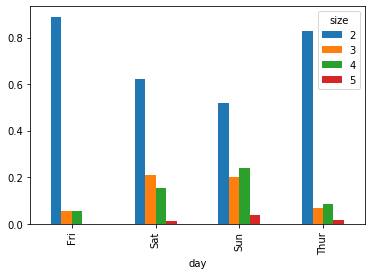

In [37]:
# Normalize to sum to 1
party_pcts = party_counts.div(party_counts.sum(1), axis=0)
party_pcts
party_pcts.plot.bar()

In [38]:
plt.close('all')

##### With data that requires aggregation or summaries before making a plot, using seaborn library can simplify coding.

In [39]:
import seaborn as sns
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


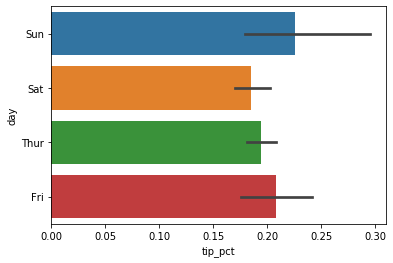

In [40]:
sns.barplot(x='tip_pct', y='day', data=tips, orient='h')

In [41]:
plt.close('all')

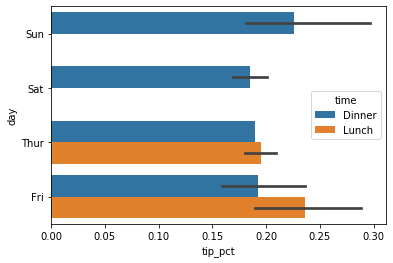

In [42]:
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h')

In [43]:
plt.close('all')

In [44]:
sns.set(style="whitegrid")

### Histograms and Density Plots

In [45]:
plt.figure()

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

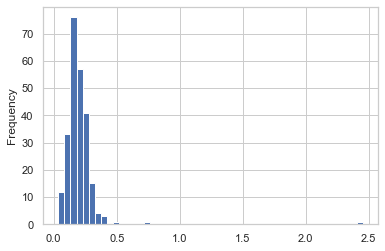

In [46]:
tips['tip_pct'].plot.hist(bins=50)

In [47]:
plt.figure()

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

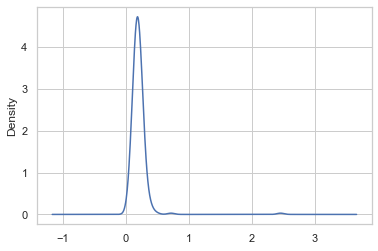

In [48]:
tips['tip_pct'].plot.density()

In [49]:
plt.close('all')
plt.figure()

<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

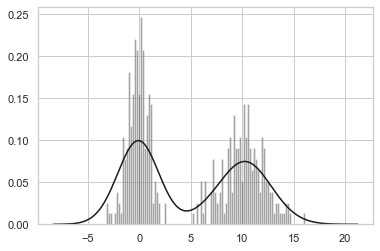

In [50]:
comp1 = np.random.normal(0, 1, size=200)
comp2 = np.random.normal(10, 2, size=200)
values = pd.Series(np.concatenate([comp1, comp2]))
sns.distplot(values, bins=100, color='k')

### Scatter or Point Plots

In [51]:
macro = pd.read_csv('examples/macrodata.csv')
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
trans_data = np.log(data).diff().dropna()
trans_data[-5:]

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


In [52]:
plt.close('all')

Text(0.5, 1.0, 'Changes in log m1 versus log unemp')

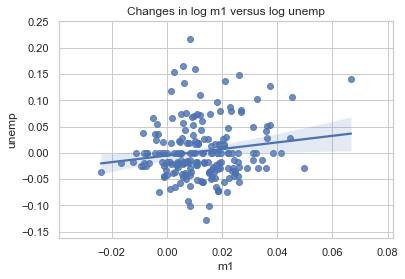

In [59]:
sns.regplot('m1', 'unemp', data=trans_data, ci=95)
plt.title('Changes in log %s versus log %s' % ('m1', 'unemp'))

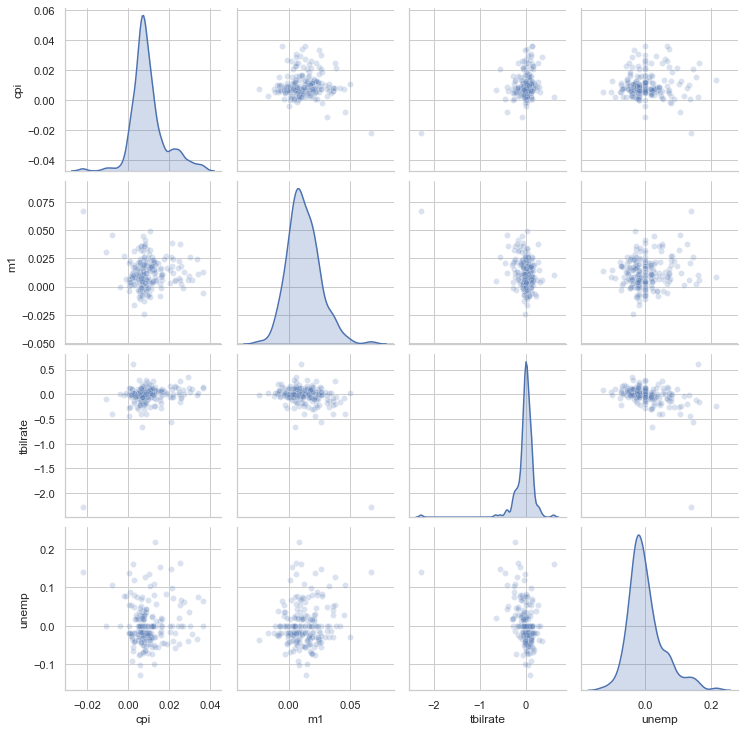

In [54]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha': 0.2})

In [55]:
plt.close('all')

### Facet Grids and Categorical Data

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


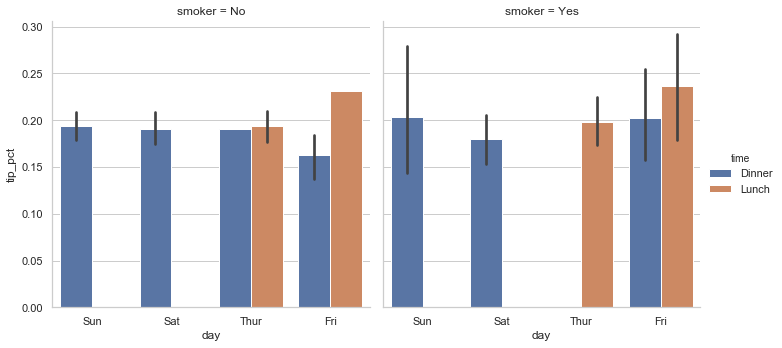

In [56]:
sns.factorplot(x='day', y='tip_pct', hue='time', col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


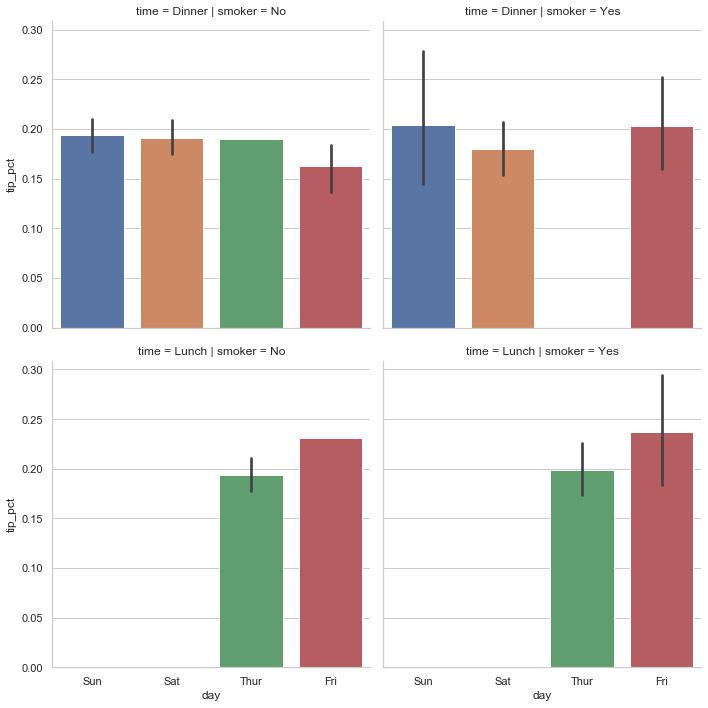

In [57]:
plt.close('all')
sns.factorplot(x='day', y='tip_pct', row='time',
               col='smoker',
               kind='bar', data=tips[tips.tip_pct < 1])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:3669: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


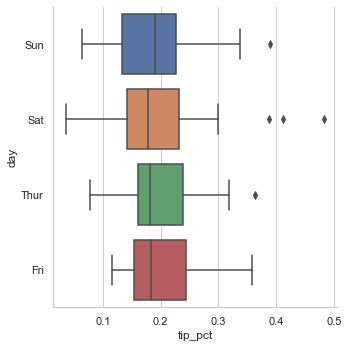

In [58]:
sns.factorplot(x='tip_pct', y='day', kind='box',
               data=tips[tips.tip_pct < 0.5])